<a href="https://colab.research.google.com/github/rijosudu123/ict-assessment/blob/main/ML_CASESTUDY.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [94]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder,OrdinalEncoder
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

In [95]:
data = pd.read_csv("/content/train_LZdllcl.csv")
data

,employee_id,department,region,education,gender,recruitment_channel,no_of_trainings,age,previous_year_rating,length_of_service,KPIs_met >80%,awards_won?,avg_training_score,is_promoted
0,65438,Sales & Marketing,region_7,Master's & above,f,sourcing,1,35,5.0,8,1,0,49,0
1,65141,Operations,region_22,Bachelor's,m,other,1,30,5.0,4,0,0,60,0
2,7513,Sales & Marketing,region_19,Bachelor's,m,sourcing,1,34,3.0,7,0,0,50,0
3,2542,Sales & Marketing,region_23,Bachelor's,m,other,2,39,1.0,10,0,0,50,0
4,48945,Technology,region_26,Bachelor's,m,other,1,45,3.0,2,0,0,73,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
54803,3030,Technology,region_14,Bachelor's,m,sourcing,1,48,3.0,17,0,0,78,0
54804,74592,Operations,region_27,Master's & above,f,other,1,37,2.0,6,0,0,56,0
54805,13918,Analytics,region_1,Bachelor's,m,other,1,27,5.0,3,1,0,79,0
54806,13614,Sales & Marketing,region_9,NaN,m,sourcing,1,29,1.0,2,0,0,45,0


In [96]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 54808 entries, 0 to 54807
Data columns (total 14 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   employee_id           54808 non-null  int64  
 1   department            54808 non-null  object 
 2   region                54808 non-null  object 
 3   education             52399 non-null  object 
 4   gender                54808 non-null  object 
 5   recruitment_channel   54808 non-null  object 
 6   no_of_trainings       54808 non-null  int64  
 7   age                   54808 non-null  int64  
 8   previous_year_rating  50684 non-null  float64
 9   length_of_service     54808 non-null  int64  
 10  KPIs_met >80%         54808 non-null  int64  
 11  awards_won?           54808 non-null  int64  
 12  avg_training_score    54808 non-null  int64  
 13  is_promoted           54808 non-null  int64  
dtypes: float64(1), int64(8), object(5)
memory usage: 5.9+ MB


In [97]:
data.isna().sum()

,0
employee_id,0
department,0
region,0
education,2409
gender,0
recruitment_channel,0
no_of_trainings,0
age,0
previous_year_rating,4124
length_of_service,0


In [118]:
data['eductaion'] = data['education'].fillna(data['education'].mode()[0])

In [119]:
data.isna().sum()

,0
employee_id,0
department,0
region,0
education,0
gender,0
recruitment_channel,0
no_of_trainings,0
age,0
previous_year_rating,4124
length_of_service,0


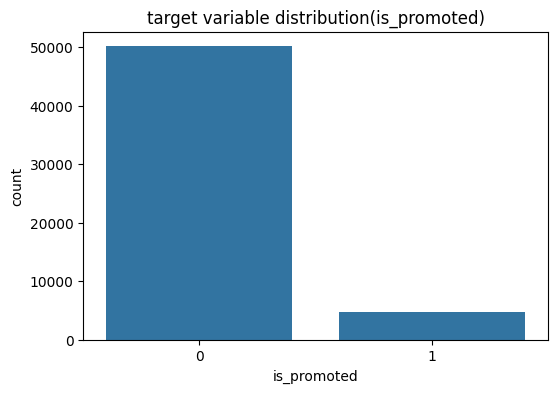

In [100]:
plt.figure(figsize=(6,4))
sns.countplot(x='is_promoted',data=data)
plt.title('target variable distribution(is_promoted)')
plt.show()

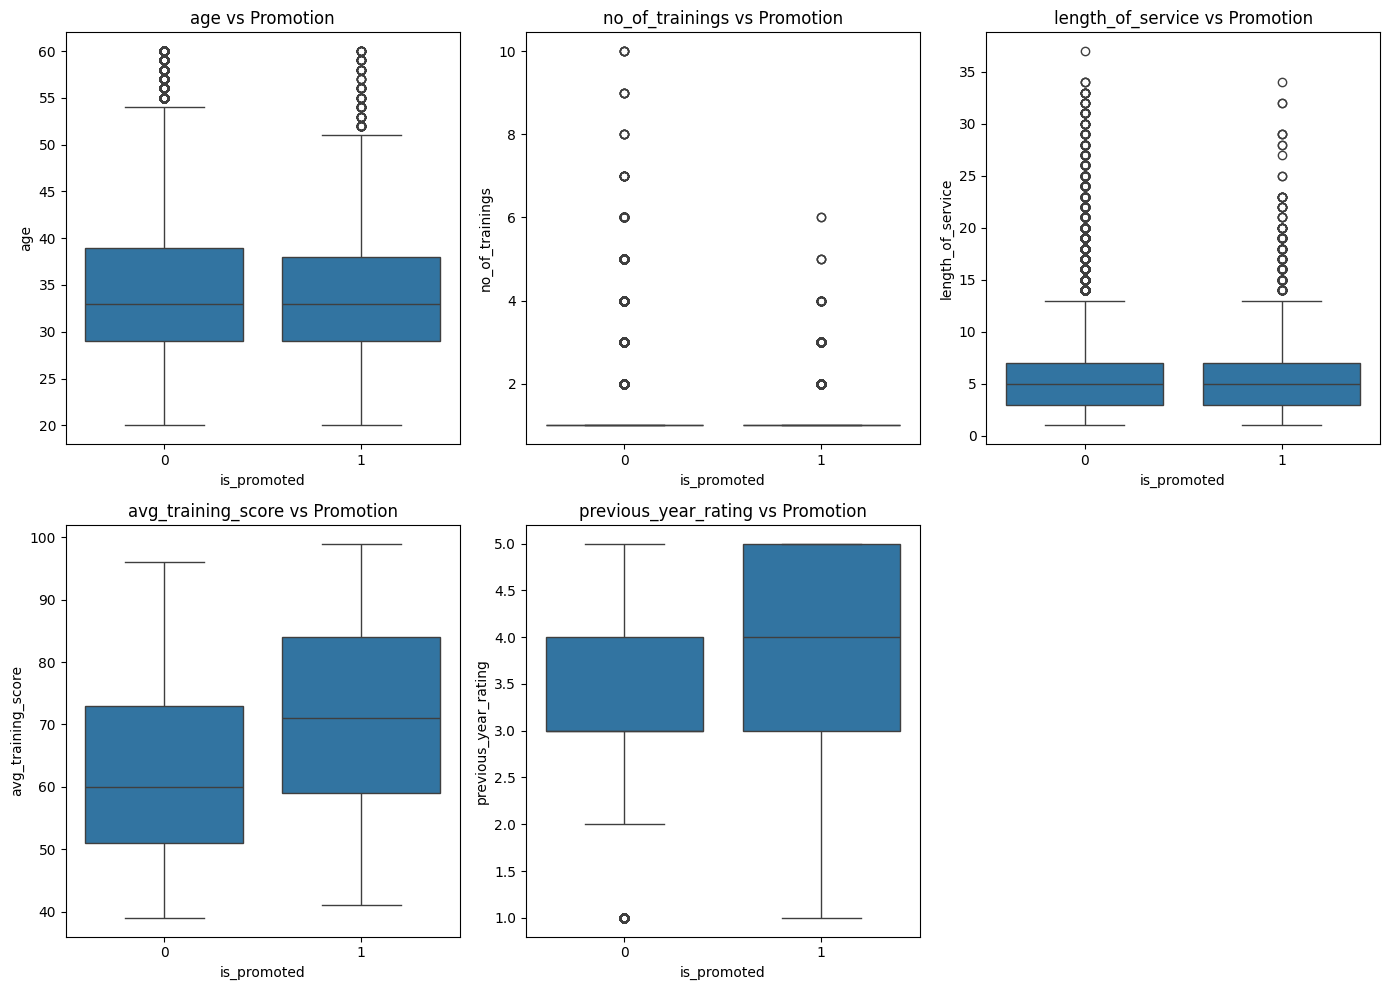

In [101]:
num_cols = ['age', 'no_of_trainings', 'length_of_service', 'avg_training_score', 'previous_year_rating']

plt.figure(figsize=(14, 10))
for i, col in enumerate(num_cols, 1):
    plt.subplot(2, 3, i)
    sns.boxplot(x='is_promoted', y=col, data=data)
    plt.title(f'{col} vs Promotion')
plt.tight_layout()
plt.show()

/tmp/ipykernel_670/3110032850.py:6: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.barplot(x=col, y='is_promoted', data=data, ci=None)
/tmp/ipykernel_670/3110032850.py:6: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.barplot(x=col, y='is_promoted', data=data, ci=None)
/tmp/ipykernel_670/3110032850.py:6: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.barplot(x=col, y='is_promoted', data=data, ci=None)
/tmp/ipykernel_670/3110032850.py:6: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.barplot(x=col, y='is_promoted', data=data, ci=None)
/tmp/ipykernel_670/3110032850.py:6: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.barplot(x=col, y='is_promoted', data=data, ci=None)


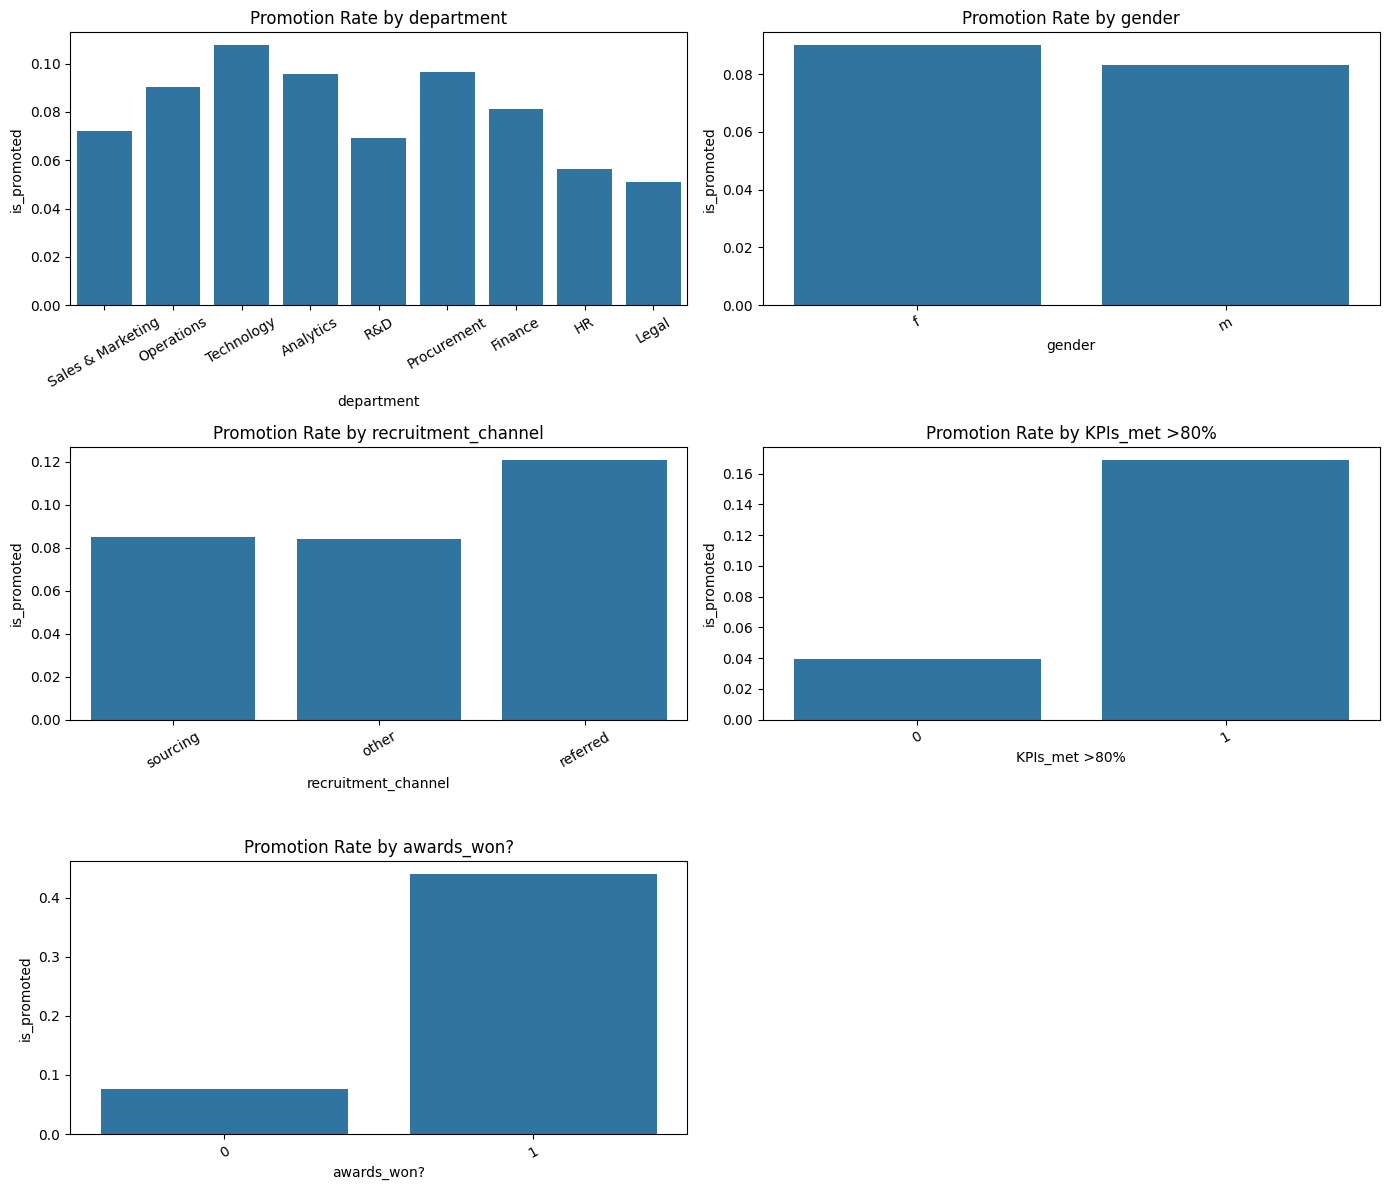

In [102]:
cat_cols = ['department', 'gender', 'recruitment_channel', 'KPIs_met >80%', 'awards_won?']

plt.figure(figsize=(14, 12))
for i, col in enumerate(cat_cols, 1):
    plt.subplot(3, 2, i)
    sns.barplot(x=col, y='is_promoted', data=data, ci=None)
    plt.xticks(rotation=30)
    plt.title(f'Promotion Rate by {col}')
plt.tight_layout()
plt.show()

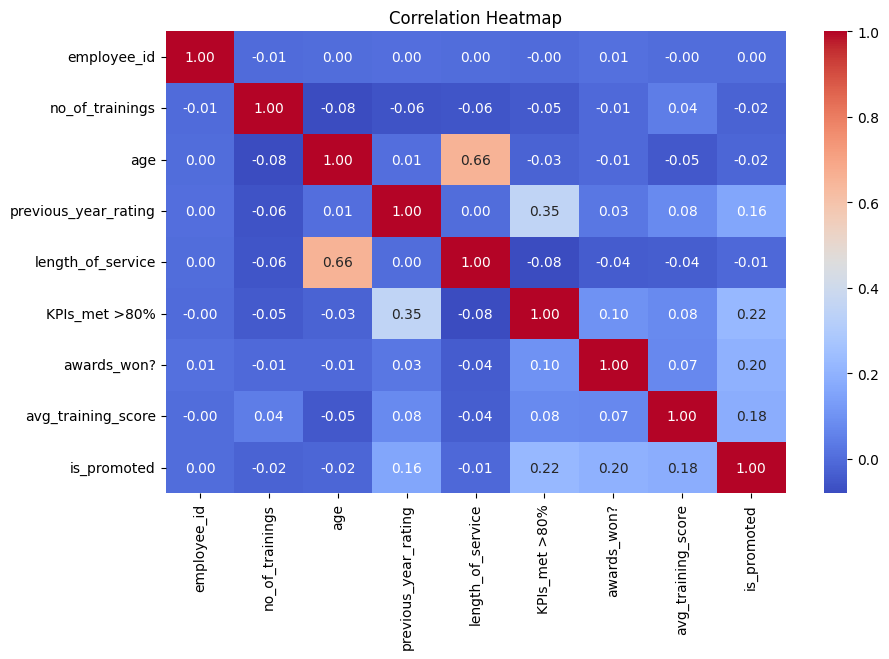

In [103]:
plt.figure(figsize=(10, 6))
numeric_data = data.select_dtypes(include=[np.number])
sns.heatmap(numeric_data.corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Heatmap')
plt.show()

In [104]:
label_enc=LabelEncoder()
cat_cols = ['department', 'region',  'gender', 'recruitment_channel']
for i in cat_cols:
  data[i] = label_enc.fit_transform(data[i].astype(str))


In [105]:
data.isna().sum()

,0
employee_id,0
department,0
region,0
education,2409
gender,0
recruitment_channel,0
no_of_trainings,0
age,0
previous_year_rating,4124
length_of_service,0


np.int64(0)

In [113]:
data['education'].value_counts()

,count
education,
1.0,39078
2.0,14925
0.0,805


In [109]:
education_order = [["Below Secondary", "Bachelor's", "Master's & above"]]
ord_enc = OrdinalEncoder(categories=education_order)
data['education'] = ord_enc.fit_transform(data[['education']])

In [114]:
data

,employee_id,department,region,education,gender,recruitment_channel,no_of_trainings,age,previous_year_rating,length_of_service,KPIs_met >80%,awards_won?,avg_training_score,is_promoted,eductaion
0,65438,7,31,2.0,0,2,1,35,5.0,8,1,0,49,0,Master's & above
1,65141,4,14,1.0,1,0,1,30,5.0,4,0,0,60,0,Bachelor's
2,7513,7,10,1.0,1,2,1,34,3.0,7,0,0,50,0,Bachelor's
3,2542,7,15,1.0,1,0,2,39,1.0,10,0,0,50,0,Bachelor's
4,48945,8,18,1.0,1,0,1,45,3.0,2,0,0,73,0,Bachelor's
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
54803,3030,8,5,1.0,1,2,1,48,3.0,17,0,0,78,0,Bachelor's
54804,74592,4,19,2.0,0,0,1,37,2.0,6,0,0,56,0,Master's & above
54805,13918,0,0,1.0,1,0,1,27,5.0,3,1,0,79,0,Bachelor's
54806,13614,7,33,1.0,1,2,1,29,1.0,2,0,0,45,0,NaN


In [115]:
X = data.drop(columns=['is_promoted', 'employee_id', 'eductaion'], errors='ignore')
y = data['is_promoted']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)



In [116]:
model = RandomForestClassifier(random_state=42)
model.fit(X_train, y_train)
y_pred = model.predict(X_test)



In [117]:
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import RandomForestClassifier
param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [10, 20, None],
    'min_samples_split': [2, 5],
    'criterion': ['gini', 'entropy']
}
rf = RandomForestClassifier(random_state=42)
grid_search = GridSearchCV(estimator=rf, param_grid=param_grid, cv=3, scoring='f1', n_jobs=-1, verbose=1)
grid_search.fit(X_train, y_train)
print("Best Parameters:", grid_search.best_params_)
best_model = grid_search.best_estimator_
y_pred_tuned = best_model.predict(X_test)
print(f"Tuned Accuracy Score: {accuracy_score(y_test, y_pred_tuned) * 100:.2f}%")
print("\n--- Tuned Classification Report ---")
print(classification_report(y_test, y_pred_tuned))

Fitting 3 folds for each of 24 candidates, totalling 72 fits
Best Parameters: {'criterion': 'entropy', 'max_depth': None, 'min_samples_split': 2, 'n_estimators': 200}
Tuned Accuracy Score: 93.50%

--- Tuned Classification Report ---
              precision    recall  f1-score   support

           0       0.94      0.99      0.97     10028
           1       0.84      0.29      0.44       934

    accuracy                           0.93     10962
   macro avg       0.89      0.64      0.70     10962
weighted avg       0.93      0.93      0.92     10962

